<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import seaborn as sns

# Carregar o conjunto de dados Iris
iris = load_iris()

# Criar um DataFrame com as características
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
from sklearn.model_selection import train_test_split
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
print("X train", X_train.shape[0])
print("X test:", X_test.shape[0])

X train 135
X test: 15


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_end_train = model.predict(X_train)
y_end_test = model.predict(X_test)
acc_train = accuracy_score(y_train, y_end_train)
acc_test = accuracy_score(y_test, y_end_test)

print(f"Acc train: {acc_train:.2f}")
print(f"Acc test: {acc_test:.2f}")

Acc train: 1.00
Acc test: 0.87


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:


[Text(0.4, 0.9166666666666666, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 135\nvalue = [45, 45, 45]\nclass = setosa'),
 Text(0.3, 0.75, 'gini = 0.0\nsamples = 45\nvalue = [45, 0, 0]\nclass = setosa'),
 Text(0.35, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'petal width (cm) <= 1.65\ngini = 0.5\nsamples = 90\nvalue = [0, 45, 45]\nclass = versicolor'),
 Text(0.45, 0.8333333333333333, '  False'),
 Text(0.2, 0.5833333333333334, 'petal length (cm) <= 4.95\ngini = 0.12\nsamples = 47\nvalue = [0.0, 44.0, 3.0]\nclass = versicolor'),
 Text(0.1, 0.4166666666666667, 'gini = 0.0\nsamples = 43\nvalue = [0, 43, 0]\nclass = versicolor'),
 Text(0.3, 0.4166666666666667, 'sepal length (cm) <= 6.15\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]\nclass = virginica'),
 Text(0.2, 0.25, 'sepal width (cm) <= 2.45\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]\nclass = versicolor'),
 Text(0.1, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.3, 0.083333333

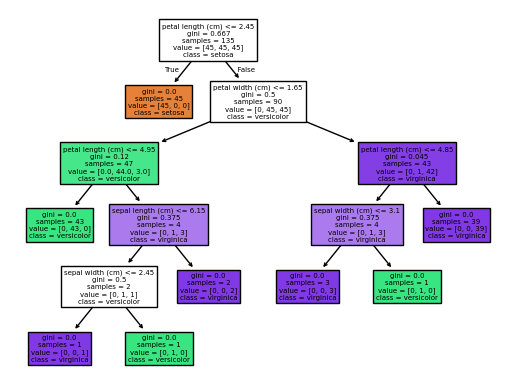

In [61]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

**Adicione seu texto de solução aqui**.

1.   Petal lenght
2.   5



# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [62]:
model = {}
y_end_train = {}
y_end_test = {}
acc_train = {}
acc_test = {}
depth = {}
leave = {}

depths = list(range(1, 10)) + [None]

for d in depths:
    model[d] = DecisionTreeClassifier(max_depth=d, random_state=42)
    model[d].fit(X_train, y_train)

    y_end_train[d] = model[d].predict(X_train)
    y_end_test[d] = model[d].predict(X_test)

    acc_train[d] = accuracy_score(y_train, y_end_train[d])
    acc_test[d] = accuracy_score(y_test, y_end_test[d])
    depth[d] = model[d].tree_.max_depth
    leave[d] = model[d].get_n_leaves()

    print(f"max_depth = {d} | acc treino = {acc_train[d]:.2f} | acc teste = {acc_test[d]:.2f} | tree depth = {depth[d]} | n leaves = {leave[d]}")

max_depth = 1 | acc treino = 0.67 | acc teste = 0.67 | tree depth = 1 | n leaves = 2
max_depth = 2 | acc treino = 0.97 | acc teste = 0.87 | tree depth = 2 | n leaves = 3
max_depth = 3 | acc treino = 0.99 | acc teste = 0.93 | tree depth = 3 | n leaves = 5
max_depth = 4 | acc treino = 0.99 | acc teste = 0.87 | tree depth = 4 | n leaves = 7
max_depth = 5 | acc treino = 1.00 | acc teste = 0.87 | tree depth = 5 | n leaves = 8
max_depth = 6 | acc treino = 1.00 | acc teste = 0.87 | tree depth = 5 | n leaves = 8
max_depth = 7 | acc treino = 1.00 | acc teste = 0.87 | tree depth = 5 | n leaves = 8
max_depth = 8 | acc treino = 1.00 | acc teste = 0.87 | tree depth = 5 | n leaves = 8
max_depth = 9 | acc treino = 1.00 | acc teste = 0.87 | tree depth = 5 | n leaves = 8
max_depth = None | acc treino = 1.00 | acc teste = 0.87 | tree depth = 5 | n leaves = 8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

O overfitting começa a aparecer a partir de 4.
O None não limita a profundidade, continuando no nomero máximos de folhas

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [63]:

model_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
model_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)

model_gini.fit(X_train, y_train)
model_entropy.fit(X_train, y_train)

acc_gini = accuracy_score(y_test, model_gini.predict(X_test))
acc_entropy = accuracy_score(y_test, model_entropy.predict(X_test))

print(f'gini    | profundidade = {model_gini.tree_.max_depth} | acurácia = {acc_gini:.4f}')
print(f'entropy | profundidade = {model_entropy.tree_.max_depth} | acurácia = {acc_entropy:.4f}')

gini    | profundidade = 5 | acurácia = 0.8667
entropy | profundidade = 5 | acurácia = 0.8667


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

Melhor modelo encontrado (questão 4): DecisionTreeClassifier(max_depth=3, random_state=42)
Acurácia: 0.93 no conjunto de teste
OBS: Coonjunto de teste = 0.1


Com valores mais baixos, o modelo fica simples demais e acerta menos. Com valores muito altos, a árvore se ajusta demais aos dados de treino, causando overfitting. Nesse caso, max_depth=3 apresentou o melhor equilíbrio entre desempenho e generalização.